# Leaf Disease Prediction Testing
This notebook allows you to test the trained MobileNetV2 model on individual leaf images.

### Instructions:
1. Ensure your model checkpoint (`cnn_mobilenet_pytorch_final.pt`) is in the `SHASHANK/` folder.
2. Update the `image_path` variable with the path to the leaf image you want to test.

In [35]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Define Model Architecture
The class definition must match the one used during training.

In [36]:
class PlantDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseModel, self).__init__()
        self.base_model = models.mobilenet_v2(weights=None)
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        return self.base_model(x)

## 2. Configuration and Labels

In [37]:
# List of all 39 classes in alphabetical order (as loaded by ImageFolder)
CLASS_NAMES = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy',
    'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight',
    'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy',
    'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy'
]

MODEL_PATH = 'SHASHANK/cnn_mobilenet_pytorch_final.pt'
num_classes = len(CLASS_NAMES)

# Preprocessing transforms
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## 3. Loading the Model

In [38]:
def load_trained_model(path, num_classes):
    model = PlantDiseaseModel(num_classes)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

try:
    model = load_trained_model(MODEL_PATH, num_classes)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")

Model loaded successfully!


## 4. Run Prediction

In [39]:
def predict_image(image_path, model, transform, class_names):
    if not os.path.exists(image_path):
        print(f"File not found: {image_path}")
        return
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Perform inference
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        conf, pred = torch.max(probabilities, dim=0)
    
    label = class_names[pred.item()]
    
    # Visualize results
    plt.imshow(image)
    plt.title(f"Prediction: {label}\nConfidence: {conf.item():.2%}")
    plt.axis('off')
    plt.show()
    
    return label, conf.item()

### Test Image Path
Set your image path below and run the cell!

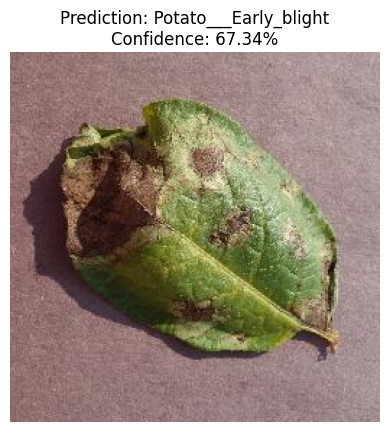

In [40]:
# UPDATE THIS PATH
image_path = r"D:\Esiot_project\DATASET\Original\Potato___Late_blight\image (994).JPG"

prediction, confidence = predict_image(image_path, model, inference_transforms, CLASS_NAMES)